In [ ]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set(color_codes=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#load the dataset
df = pd.read_csv('/content/drive/MyDrive/DataClass/retail_sales_dataset.csv')

**DATA CLEANING**

In [ ]:
df.head()

,Date,Customer ID,Gender,Age,Age_Group,Product Category,Quantity,Cost Price,Price per Unit,Revenue,Profit Per Unit,Profit
0,11/24/2023,CUST001,Male,34,Adult,Beauty,3,40,50,150,10,30
1,2/27/2023,CUST002,Female,26,Young_Adult,Clothing,2,400,500,1000,100,200
2,1/13/2023,CUST003,Male,50,Mid-Age_Adult,Electronics,1,24,30,30,6,6
3,5/21/2023,CUST004,Male,37,Adult,Clothing,1,400,500,500,100,100
4,5/6/2023,CUST005,Male,30,Adult,Beauty,2,40,50,100,10,20


In [ ]:
df.shape

(1000, 12)

In [ ]:
df.size

12000

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              1000 non-null   object
 1   Customer ID       1000 non-null   object
 2   Gender            1000 non-null   object
 3   Age               1000 non-null   int64 
 4   Age_Group         1000 non-null   object
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Cost Price        1000 non-null   int64 
 8   Price per Unit    1000 non-null   int64 
 9   Revenue           1000 non-null   int64 
 10  Profit Per Unit   1000 non-null   int64 
 11  Profit            1000 non-null   int64 
dtypes: int64(7), object(5)
memory usage: 93.9+ KB


In [ ]:
# Check for missing Values
df.isnull().sum().sort_values(ascending=False)

,0
Date,0
Customer ID,0
Gender,0
Age,0
Age_Group,0
Product Category,0
Quantity,0
Cost Price,0
Price per Unit,0
Revenue,0


In [ ]:
# Changing of data type
df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
# Age_Group
bins = [0, 17, 25, 35, 45, 60, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)


Overall Sales & Profit Overview
**bold text**


In [ ]:
total_revenue = df['Revenue'].sum()
total_revenue

np.int64(456000)

In [ ]:
total_profit = df['Profit'].sum()
total_profit

np.int64(91200)

In [ ]:
total_quantity = df['Quantity'].sum()
total_quantity

np.int64(2514)

In [ ]:
avg_price = df['Price per Unit'].mean()
avg_price

np.float64(179.89)

In [ ]:
avg_profit = df['Profit Per Unit'].mean()
avg_profit

np.float64(35.978)

**Sales Trend Over Time**

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month', ylabel='Revenue'>

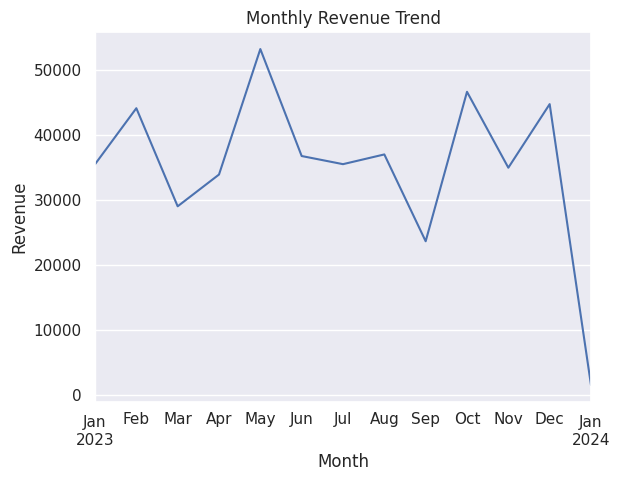

In [ ]:
# Monthly Revenue Trend
df['Month'] = df['Date'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue.plot(kind='line', title='Monthly Revenue Trend', xlabel='Month', ylabel='Revenue')



**Product Category Performance**

In [ ]:
category_performance = df.groupby('Product Category').agg({
    'Revenue':'sum',
    'Profit':'sum',
    'Quantity':'sum'
}).sort_values(by='Revenue', ascending=False)

category_performance


,Revenue,Profit,Quantity
Product Category,,,
Electronics,156905,31381,849
Clothing,155580,31116,894
Beauty,143515,28703,771


**Customer Demographics**

<Axes: title={'center': 'Revenue & Profit by Gender'}, xlabel='Gender'>

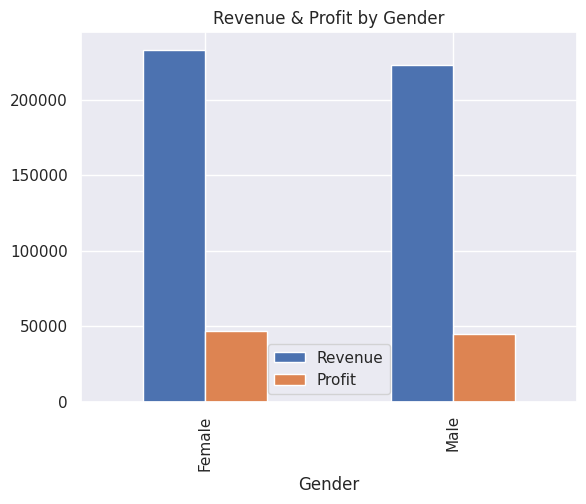

In [ ]:
# Gender Analysis
gender_sales = df.groupby('Gender')[['Revenue', 'Profit']].sum()
gender_sales.plot(kind='bar', title='Revenue & Profit by Gender')


<Axes: title={'center': 'Revenue & Profit by Age Group'}, xlabel='Age_Group'>

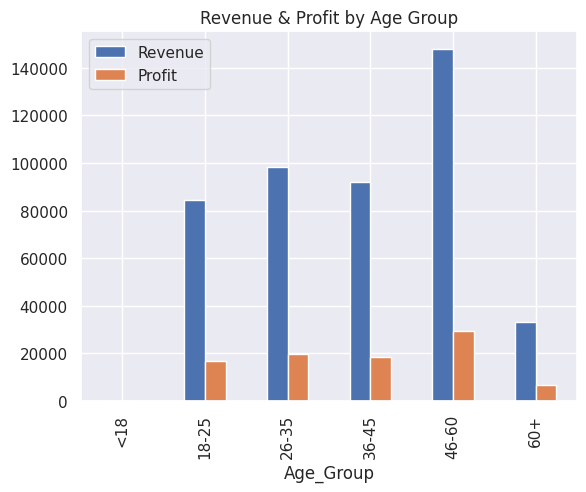

In [ ]:
# Age Group Analysis
agegroup_sales = df.groupby('Age_Group')[['Revenue', 'Profit']].sum()
agegroup_sales.plot(kind='bar', title='Revenue & Profit by Age Group')

**Profitability Check**

<Axes: title={'center': 'Average Profit Margin by Category'}, xlabel='Product Category'>

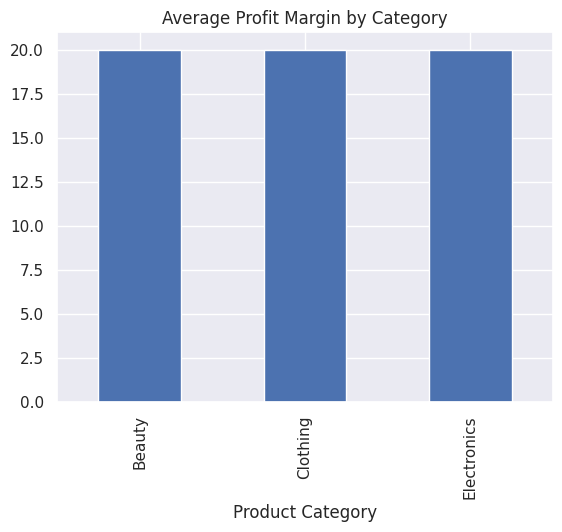

In [ ]:
df['Profit Margin (%)'] = (df['Profit'] / df['Revenue']) * 100

# Category Profit Margin
category_margin = df.groupby('Product Category')['Profit Margin (%)'].mean()
category_margin.sort_values(ascending=False).plot(kind='bar', title='Average Profit Margin by Category')


**Quantity Sold Analysis**

<Axes: title={'center': 'Top Selling Products by Quantity'}, xlabel='Product Category'>

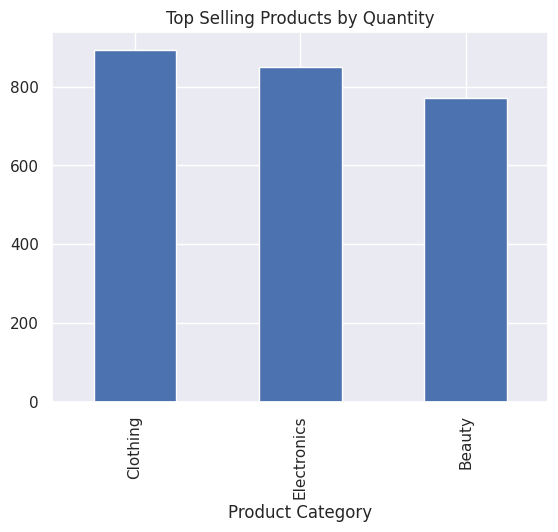

In [ ]:
top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
top_products.plot(kind='bar', title='Top Selling Products by Quantity')


In [ ]:
df.to_csv("clean_retail_sales_data.csv", index=False)
